In [3]:
import pandas as pd
import numpy as np

import seaborn as sns

# Загрузка данных

In [15]:
file_url = 'https://drive.google.com/uc?export=download&id=1pmGSMI2LuvsiBaBG5v7N8xfPedZbF020'

In [17]:
df = pd.read_csv(file_url)

In [19]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,default
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,2,49,male,1,own,little,NaN,2096,12,education,0
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,4,53,male,2,free,little,little,4870,24,car,1


# Предобработка данных

## Удаляем столбцы

In [24]:
df = df.drop('Unnamed: 0', axis = 1)

In [27]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,default
0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,NaN,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,1


## Переименовываем столбцы

In [64]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [66]:
df.head()

,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,purpose,default
0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,NaN,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,1


## Пропуски

In [71]:
df.isna().mean()

age                 0.000
sex                 0.000
job                 0.000
housing             0.000
saving_accounts     0.183
checking_account    0.394
credit_amount       0.000
duration            0.000
purpose             0.000
default             0.000
dtype: float64

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               1000 non-null   int64 
 1   sex               1000 non-null   object
 2   job               1000 non-null   int64 
 3   housing           1000 non-null   object
 4   saving_accounts   817 non-null    object
 5   checking_account  606 non-null    object
 6   credit_amount     1000 non-null   int64 
 7   duration          1000 non-null   int64 
 8   purpose           1000 non-null   object
 9   default           1000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


# Анализ

## Сводная таблица

In [89]:
(df.groupby('checking_account', dropna=False).
 agg({'default':['count', 'mean'], 
      'credit_amount':['mean', 'median']})
)

default           credit_amount        
                   count      mean          mean  median
checking_account                                        
little               274  0.492701   3175.218978  2353.5
moderate             269  0.390335   3827.561338  2622.0
rich                  63  0.222222   2177.650794  1881.0
NaN                  394  0.116751   3133.101523  2248.0

In [114]:
(df.groupby(['checking_account', 'sex'], dropna=False).
 agg({'default':['count', 'mean'], 
      'credit_amount':['mean', 'median']})
)

default           credit_amount        
                          count      mean          mean  median
checking_account sex                                           
little           female      88  0.522727   2564.215909  1838.5
                 male       186  0.478495   3464.295699  2589.5
moderate         female      86  0.476744   3720.034884  2651.0
                 male       183  0.349727   3878.092896  2520.0
rich             female      20  0.200000   1616.050000  1400.5
                 male        43  0.232558   2438.860465  1925.0
NaN              female     116  0.155172   2708.750000  1935.0
                 male       278  0.100719   3310.169065  2393.5

## Pivot table

In [110]:
df.pivot_table(dropna=False,
               index='checking_account',
               columns='sex',
               values=['default','credit_amount'], 
               aggfunc={'default':['count', 'mean'], 
                        'credit_amount':['mean', 'median']})

credit_amount                                                 \
                         count              mean               median           
sex                     female male       female         male  female    male   
checking_account                                                                
little                     NaN  NaN  2564.215909  3464.295699  1838.5  2589.5   
moderate                   NaN  NaN  3720.034884  3878.092896  2651.0  2520.0   
rich                       NaN  NaN  1616.050000  2438.860465  1400.5  1925.0   
NaN                        NaN  NaN  2708.750000  3310.169065  1935.0  2393.5   

                 default                                       
                   count           mean           median       
sex               female male    female      male female male  
checking_account                                               
little                88  186  0.522727  0.478495    NaN  NaN  
moderate              86  183  0.476744  0.349727    NaN  NaN  
rich                  20   43  0.200000  0.232558    NaN  NaN  
NaN                  116  278  0.155172  0.100719    NaN  NaN

In [112]:
df.pivot_table(dropna=False,
               index='checking_account',
               columns='sex',
               values=['default','credit_amount'], 
               aggfunc=['count', 'mean'],
               margins=True
              )

count                                    \
                 credit_amount              default                
sex                     female male     All  female male     All   
checking_account                                                   
little                      88  186   274.0      88  186   274.0   
moderate                    86  183   269.0      86  183   269.0   
rich                        20   43    63.0      20   43    63.0   
NaN                        116  278     NaN     116  278     NaN   
All                        310  690  1000.0     310  690  1000.0   

                          mean                                                \
                 credit_amount                             default             
sex                     female         male          All    female      male   
checking_account                                                               
little             2564.215909  3464.295699  3175.218978  0.522727  0.478495   
moderate           3720.034884  3878.092896  3827.561338  0.476744  0.349727   
rich               1616.050000  2438.860465  2177.650794  0.200000  0.232558   
NaN                2708.750000  3310.169065          NaN  0.155172  0.100719   
All                2877.774194  3448.040580  3271.258000  0.351613  0.276812   

                            
                            
sex                    All  
checking_account            
little            0.492701  
moderate          0.390335  
rich              0.222222  
NaN                    NaN  
All               0.300000

## Форматирование сводной таблицы

In [135]:
(df.groupby('checking_account', dropna=False).
 agg({'default':['count', 'mean']})
)

default          
                   count      mean
checking_account                  
little               274  0.492701
moderate             269  0.390335
rich                  63  0.222222
NaN                  394  0.116751

In [144]:
(df.groupby(['checking_account'])['default']
.agg(['count', 'mean'])
.sort_values('count',ascending=False)
.style
.format({
    'mean': '{:,.1%}'.format,
})
.applymap(
     lambda x: 'background-color : green' if x>0.3 else '', 
     subset=['mean']))

C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\2698554056.py:8: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(


,count,mean
checking_account,,
little,274,49.3%
moderate,269,39.0%
rich,63,22.2%


## Избавляемся от мультииндекса

t = df.pivot_table(dropna=False,
               index='checking_account',
               columns='sex',
               values=['default','credit_amount'], 
               aggfunc={'default':['count', 'mean'], 
                        'credit_amount':['mean', 'median']})
t

In [167]:
t.columns = ['_'.join(col).strip() for col in t.columns.values]

In [169]:
t

,credit_amount_count_female,credit_amount_count_male,credit_amount_mean_female,credit_amount_mean_male,credit_amount_median_female,credit_amount_median_male,default_count_female,default_count_male,default_mean_female,default_mean_male,default_median_female,default_median_male
checking_account,,,,,,,,,,,,
little,NaN,NaN,2564.215909,3464.295699,1838.5,2589.5,88,186,0.522727,0.478495,NaN,NaN
moderate,NaN,NaN,3720.034884,3878.092896,2651.0,2520.0,86,183,0.476744,0.349727,NaN,NaN
rich,NaN,NaN,1616.050000,2438.860465,1400.5,1925.0,20,43,0.200000,0.232558,NaN,NaN
NaN,NaN,NaN,2708.750000,3310.169065,1935.0,2393.5,116,278,0.155172,0.100719,NaN,NaN


## Пример анализа

In [173]:
(df.groupby('checking_account', dropna=False).
 agg({'default':['count', 'mean']})
)

default          
                   count      mean
checking_account                  
little               274  0.492701
moderate             269  0.390335
rich                  63  0.222222
NaN                  394  0.116751

Самый низкий процент должников в категории no_info

In [176]:
(df.groupby('housing', dropna=False).
 agg({'default':['count', 'mean']})
)

default          
          count      mean
housing                  
free        108  0.407407
own         713  0.260870
rent        179  0.391061

## Бины, бакеты, интервалы, группы

In [179]:
(df.groupby('credit_amount', dropna=False).
 agg({'default':['count', 'mean']})
)

default     
                count mean
credit_amount             
250                 1  0.0
276                 1  0.0
338                 1  0.0
339                 1  0.0
343                 1  0.0
...               ...  ...
15653               1  0.0
15672               1  1.0
15857               1  0.0
15945               1  1.0
18424               1  1.0

[921 rows x 2 columns]

### cut

In [181]:
df['credit_amount_group'] = pd.cut(df['credit_amount'],5)

In [183]:
df.groupby('credit_amount_group')['default'].agg(['count','mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\3721263425.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('credit_amount_group')['default'].agg(['count','mean'])


,count,mean
credit_amount_group,,
"(231.826, 3884.8]",738,0.256098
"(3884.8, 7519.6]",177,0.384181
"(7519.6, 11154.4]",57,0.403509
"(11154.4, 14789.2]",22,0.727273
"(14789.2, 18424.0]",6,0.666667


### qcut

In [190]:
df['credit_amount_group2'] = pd.qcut(df['credit_amount'],5)

In [192]:
df.groupby('credit_amount_group2')['default'].agg(['count','mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\1701320292.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('credit_amount_group2')['default'].agg(['count','mean'])


,count,mean
credit_amount_group2,,
"(249.999, 1262.0]",201,0.303483
"(1262.0, 1906.8]",199,0.241206
"(1906.8, 2852.4]",200,0.270000
"(2852.4, 4720.0]",200,0.260000
"(4720.0, 18424.0]",200,0.425000


### Произвольно

In [194]:
df['credit_amount_group3'] = pd.cut(df['credit_amount'],[0,1000,2000,3000,5000,np.inf])

In [196]:
df.groupby('credit_amount_group3')['default'].agg(['count','mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\1895611547.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('credit_amount_group3')['default'].agg(['count','mean'])


,count,mean
credit_amount_group3,,
"(0.0, 1000.0]",116,0.318966
"(1000.0, 2000.0]",316,0.265823
"(2000.0, 3000.0]",188,0.239362
"(3000.0, 5000.0]",192,0.291667
"(5000.0, inf]",188,0.414894


## Графики

C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\3186409980.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('credit_amount_group2')['default'].agg(['mean']).plot(kind='line',


<Axes: xlabel='credit_amount_group2'>

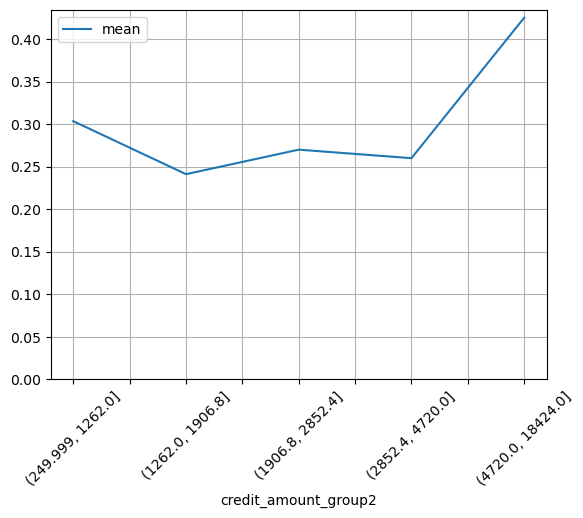

In [205]:
df.groupby('credit_amount_group2')['default'].agg(['mean']).plot(kind='line', 
                                                                 rot=45,
                                                                 ylim=0,
                                                                 grid=True)

# Переменные

## Категориальные

In [211]:
df['checking_account'].value_counts(dropna=False)

checking_account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64

In [213]:
df['checking_account'].value_counts(dropna=False, normalize=True)

checking_account
NaN         0.394
little      0.274
moderate    0.269
rich        0.063
Name: proportion, dtype: float64

In [215]:
df['default'].value_counts(dropna=False)

default
0    700
1    300
Name: count, dtype: int64

In [217]:
df['default'].value_counts(dropna=False,normalize=True)

default
0    0.7
1    0.3
Name: proportion, dtype: float64

In [219]:
df['default'].mean()

0.3

### get_dummies()

In [226]:
pd.get_dummies(df['checking_account'])

,little,moderate,rich
0,True,False,False
1,False,True,False
2,False,False,False
3,True,False,False
4,True,False,False
...,...,...,...
995,False,False,False
996,True,False,False
997,False,False,False
998,True,False,False


## Непрерывные 

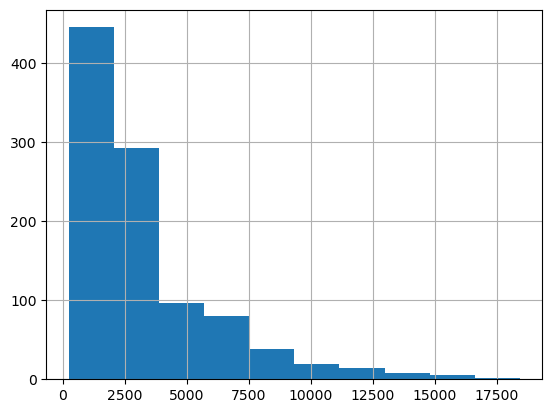

In [231]:
h = df['credit_amount'].hist()

In [233]:
def get_hist(ax):
    n,bins = [],[]
    for rect in ax.patches:
        ((x0, y0), (x1, y1)) = rect.get_bbox().get_points()
        n.append(y1-y0)
        bins.append(x0) # left edge of each bin
    bins.append(x1) # also get right edge of last bin

    return n,bins

n, bins = get_hist(h)

In [239]:
# число наблюдений в каждом интервале
n

[445.0, 293.0, 97.0, 80.0, 38.0, 19.0, 14.0, 8.0, 5.0, 1.0]

In [241]:
# интервалы
bins

[249.9999999999999,
 2067.4,
 3884.7999999999997,
 5702.200000000001,
 7519.599999999999,
 9337.0,
 11154.400000000003,
 12971.800000000001,
 14789.2,
 16606.6,
 18424.0]

## Характеристики непрерывной переменной

### Среднее

In [245]:
df['credit_amount'].mean()

3271.258

### Медиана

In [247]:
df['credit_amount'].median()

2319.5

### Boxplot

<Axes: >

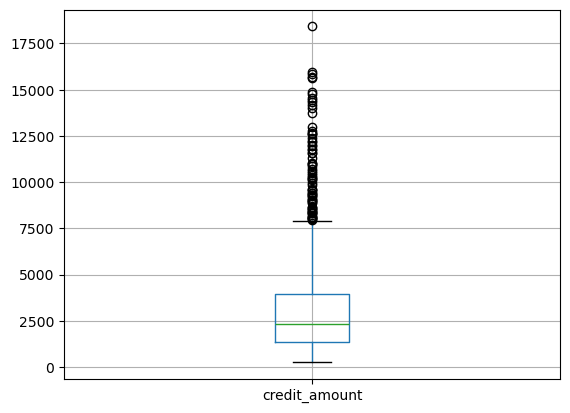

In [251]:
df.boxplot(column='credit_amount')

<Axes: title={'center': 'credit_amount'}, xlabel='checking_account'>

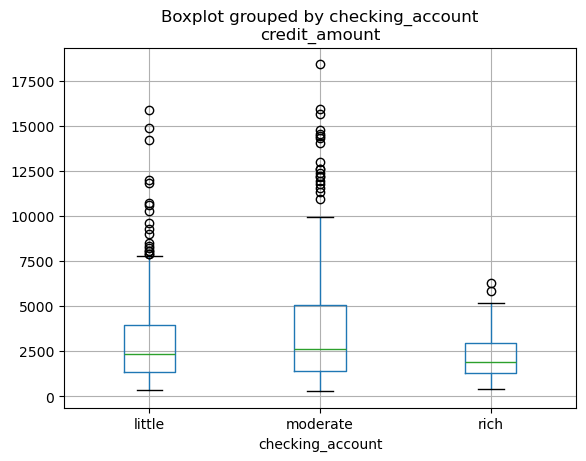

In [255]:
df.boxplot(column='credit_amount', by='checking_account')

### describe

In [260]:
df['credit_amount'].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: credit_amount, dtype: float64

In [266]:
np.var(np.array(df['credit_amount']))

7959875.627436

In [268]:
np.std(np.array(df['credit_amount']))

2821.3251545038192

## Скаттер плот

Для двух непрерывных переменных

In [274]:
df.head()

,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,purpose,default,credit_amount_group,credit_amount_group2,credit_amount_group3
0,67,male,2,own,NaN,little,1169,6,radio/TV,0,"(231.826, 3884.8]","(249.999, 1262.0]","(1000.0, 2000.0]"
1,22,female,2,own,little,moderate,5951,48,radio/TV,1,"(3884.8, 7519.6]","(4720.0, 18424.0]","(5000.0, inf]"
2,49,male,1,own,little,NaN,2096,12,education,0,"(231.826, 3884.8]","(1906.8, 2852.4]","(2000.0, 3000.0]"
3,45,male,2,free,little,little,7882,42,furniture/equipment,0,"(7519.6, 11154.4]","(4720.0, 18424.0]","(5000.0, inf]"
4,53,male,2,free,little,little,4870,24,car,1,"(3884.8, 7519.6]","(4720.0, 18424.0]","(3000.0, 5000.0]"


<Axes: xlabel='age', ylabel='credit_amount'>

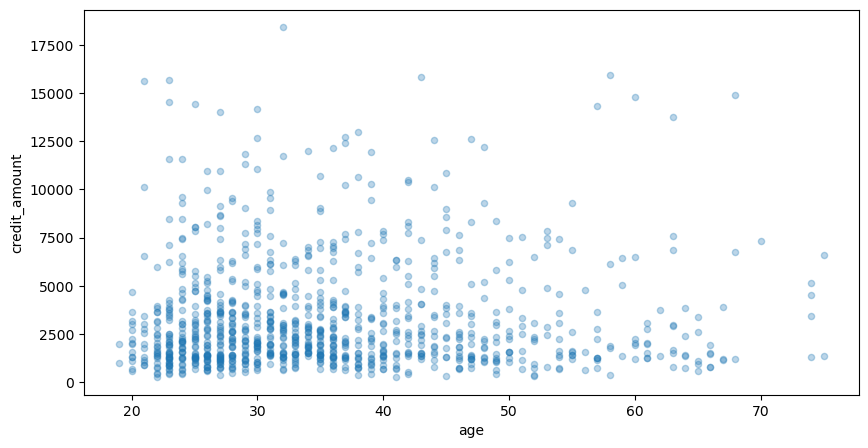

In [280]:
df.plot(x='age', y='credit_amount', kind='scatter', figsize=(10,5), alpha=0.3)

In [282]:
df['age_group'] = pd.qcut(df['age'],5)

In [284]:
df.groupby('age_group')['credit_amount'].agg(['count','mean','median'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\1531576084.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['credit_amount'].agg(['count','mean','median'])


,count,mean,median
age_group,,,
"(18.999, 26.0]",240,2987.645833,2112.5
"(26.0, 30.0]",171,3436.578947,2463.0
"(30.0, 36.0]",216,3240.439815,2427.0
"(36.0, 45.0]",187,3618.401070,2522.0
"(45.0, 75.0]",186,3172.000000,2064.0


C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\2375674157.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['credit_amount'].median().plot(ylim=0,grid=True)


<Axes: xlabel='age_group'>

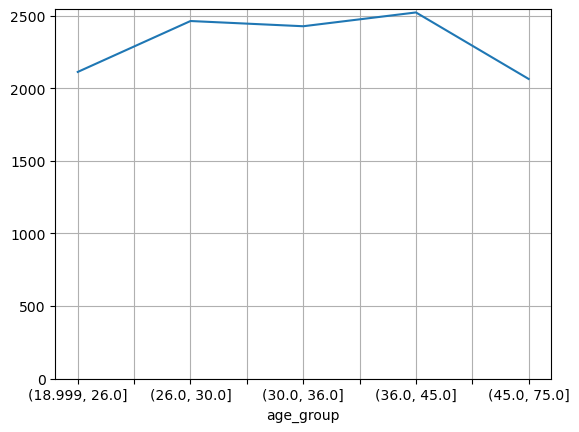

In [286]:
df.groupby('age_group')['credit_amount'].median().plot(ylim=0,grid=True)

## Корреляция

In [289]:
df[['age','credit_amount']].corr()

,age,credit_amount
age,1.000000,0.032716
credit_amount,0.032716,1.000000


# Реальный анализ

Age (numeric)  
Sex (text: male, female)  
Job (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)  
Housing (text: own, rent, or free)  
Saving accounts (text - little, moderate, quite rich, rich)  
Checking account (numeric, in DM - Deutsch Mark)  
Credit amount (numeric, in DM)  
Duration (numeric, in month)  
Purpose (text: car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others)  
Default (1-bad, 0-good)

## Предобработка данных

In [293]:
file_url = 'https://drive.google.com/uc?export=download&id=1pmGSMI2LuvsiBaBG5v7N8xfPedZbF020'

In [295]:
df = pd.read_csv(file_url)

In [297]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,default
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,2,49,male,1,own,little,NaN,2096,12,education,0
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,4,53,male,2,free,little,little,4870,24,car,1


In [299]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [301]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,default
0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,NaN,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,1


In [303]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [305]:
df.head()

,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,purpose,default
0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,NaN,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,1


In [307]:
df.isna().mean()

age                 0.000
sex                 0.000
job                 0.000
housing             0.000
saving_accounts     0.183
checking_account    0.394
credit_amount       0.000
duration            0.000
purpose             0.000
default             0.000
dtype: float64

In [311]:
df.fillna({'saving_accounts':'no_info', 'checking_account':'no_info'}, inplace=True)

In [313]:
df.isna().mean()

age                 0.0
sex                 0.0
job                 0.0
housing             0.0
saving_accounts     0.0
checking_account    0.0
credit_amount       0.0
duration            0.0
purpose             0.0
default             0.0
dtype: float64

## Анализ

In [321]:
df['age_group'] = pd.qcut(df['age'],5)

In [329]:
df.groupby('age_group', observed=True)['default'].agg(['count','mean'])

,count,mean
age_group,,
"(18.999, 26.0]",240,0.391667
"(26.0, 30.0]",171,0.315789
"(30.0, 36.0]",216,0.259259
"(36.0, 45.0]",187,0.262032
"(45.0, 75.0]",186,0.252688


<Axes: xlabel='age_group'>

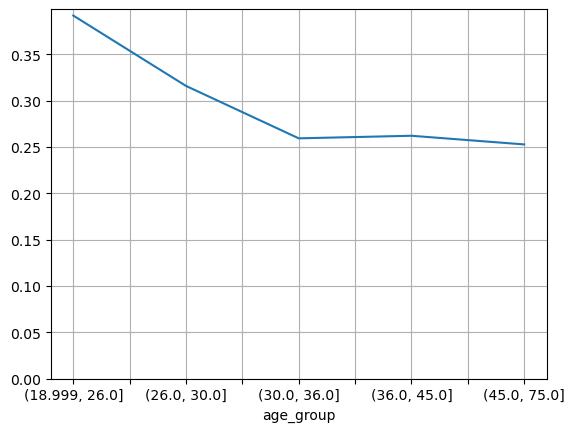

In [327]:
df.groupby('age_group', observed=True)['default'].mean().plot(ylim=0,grid=True)

С увеличением возраста процент дефолтников снижается!

In [332]:
df.groupby('sex', observed=True)['default'].agg(['count','mean'])

,count,mean
sex,,
female,310,0.351613
male,690,0.276812


Выборка перекошена -- мужчин в 2 раза больше чем женщин. И среди женщин дефолта сильно больше. Возможно влияние другой переменной? Возраст?

In [336]:
df.groupby('sex', observed=True)['age'].agg(['count','mean'])

,count,mean
sex,,
female,310,32.803226
male,690,36.778261


Действительно! Женщины в этой выборке моложе! Посмотрим в разрезе пола и возраста

In [340]:
df['age_group2'] = pd.qcut(df['age'],3)

In [345]:
df.groupby(['age_group2', 'sex'], observed=True)['default'].agg(['count','mean'])

count      mean
age_group2     sex                    
(18.999, 28.0] female    154  0.409091
               male      180  0.327778
(28.0, 38.0]   female     83  0.385542
               male      263  0.235741
(38.0, 75.0]   female     73  0.191781
               male      247  0.283401

В молодом и среднем возрасте женщины хуже возвращают долг, а в более старшем наоборот: женщины возвращают долг лучше чем мужчины

0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled

In [354]:
job_dict = {0:'unskilled and non-resident', 1:'unskilled and resident', 2:'skilled', 3:'highly skilled'}

In [360]:
df['job'] = df['job'].map(job_dict)

In [367]:
df.groupby('job', observed=True)['default'].agg(['count','mean'])

,count,mean
job,,
highly skilled,148,0.344595
skilled,630,0.295238
unskilled and non-resident,22,0.318182
unskilled and resident,200,0.280000


Странно, что в skilled самый высокий дефолт. Возможно влияние другой перменной

In [365]:
df.groupby(['job','age_group2'])['default'].agg(['count','mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\2220916620.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['job','age_group2'])['default'].agg(['count','mean'])


count      mean
job                        age_group2                     
highly skilled             (18.999, 28.0]     21  0.523810
                           (28.0, 38.0]       68  0.220588
                           (38.0, 75.0]       59  0.423729
skilled                    (18.999, 28.0]    240  0.350000
                           (28.0, 38.0]      220  0.268182
                           (38.0, 75.0]      170  0.252941
unskilled and non-resident (18.999, 28.0]      9  0.555556
                           (28.0, 38.0]        4  0.250000
                           (38.0, 75.0]        9  0.111111
unskilled and resident     (18.999, 28.0]     64  0.343750
                           (28.0, 38.0]       54  0.351852
                           (38.0, 75.0]       82  0.182927

В skilled много молодых и это влияет на уровень дефолта, тк мы видели, что у молодых дефолт выше

In [369]:
df.groupby('job')['credit_amount'].agg(['count','mean','median'])

,count,mean,median
job,,,
highly skilled,148,5435.493243,4459.0
skilled,630,3070.965079,2324.0
unskilled and non-resident,22,2745.136364,1416.0
unskilled and resident,200,2358.520000,1622.0


Но похоже, что главное влияние оказывает размер кредита! В hs и s размер кредита выше чем в unskilled. Посмотрим на влияние размера кредита на дефолт вообще

In [371]:
df['credit_amount_group'] = pd.qcut(df['credit_amount'],5)

In [373]:
df.groupby('credit_amount_group')['default'].agg(['count','mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\3721263425.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('credit_amount_group')['default'].agg(['count','mean'])


,count,mean
credit_amount_group,,
"(249.999, 1262.0]",201,0.303483
"(1262.0, 1906.8]",199,0.241206
"(1906.8, 2852.4]",200,0.270000
"(2852.4, 4720.0]",200,0.260000
"(4720.0, 18424.0]",200,0.425000


Да, чем больше кредит, тем выше дефолт рейт.

In [378]:
df.head()

,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,purpose,default,age_group,age_group2,credit_amount_group
0,67,male,skilled,own,no_info,little,1169,6,radio/TV,0,"(45.0, 75.0]","(38.0, 75.0]","(249.999, 1262.0]"
1,22,female,skilled,own,little,moderate,5951,48,radio/TV,1,"(18.999, 26.0]","(18.999, 28.0]","(4720.0, 18424.0]"
2,49,male,unskilled and resident,own,little,no_info,2096,12,education,0,"(45.0, 75.0]","(38.0, 75.0]","(1906.8, 2852.4]"
3,45,male,skilled,free,little,little,7882,42,furniture/equipment,0,"(36.0, 45.0]","(38.0, 75.0]","(4720.0, 18424.0]"
4,53,male,skilled,free,little,little,4870,24,car,1,"(45.0, 75.0]","(38.0, 75.0]","(4720.0, 18424.0]"


In [380]:
df.groupby('housing')['default'].agg(['count','mean'])

,count,mean
housing,,
free,108,0.407407
own,713,0.260870
rent,179,0.391061


Если дом в собственности, то дефолт гораздо ниже.

In [393]:
df['duration_group'] = pd.qcut(df['duration'],3)

In [395]:
df.groupby('duration_group')['default'].agg(['count','mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\3967018988.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('duration_group')['default'].agg(['count','mean'])


,count,mean
duration_group,,
"(3.999, 12.0]",359,0.211699
"(12.0, 24.0]",411,0.296837
"(24.0, 72.0]",230,0.443478


чем больше срок, тем выше вероятность дефолта

In [399]:
df.groupby(['duration_group', 'credit_amount_group'])['default'].agg(['count','mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\826680571.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['duration_group', 'credit_amount_group'])['default'].agg(['count','mean'])


count      mean
duration_group credit_amount_group                 
(3.999, 12.0]  (249.999, 1262.0]      146  0.267123
               (1262.0, 1906.8]        99  0.171717
               (1906.8, 2852.4]        63  0.126984
               (2852.4, 4720.0]        37  0.135135
               (4720.0, 18424.0]       14  0.500000
(12.0, 24.0]   (249.999, 1262.0]       54  0.407407
               (1262.0, 1906.8]        95  0.294737
               (1906.8, 2852.4]       103  0.291262
               (2852.4, 4720.0]       104  0.230769
               (4720.0, 18424.0]       55  0.327273
(24.0, 72.0]   (249.999, 1262.0]        1  0.000000
               (1262.0, 1906.8]         5  0.600000
               (1906.8, 2852.4]        34  0.470588
               (2852.4, 4720.0]        59  0.389831
               (4720.0, 18424.0]      131  0.458015

Могу дополнить. Чем больше срок, тем выше вероятность дефолта, тк на большой срок берут большие суммы. И просто по большим суммам мы видим, что уровень дефолта выше.

In [404]:
df.head()

,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,purpose,default,age_group,age_group2,credit_amount_group,duration_group
0,67,male,skilled,own,no_info,little,1169,6,radio/TV,0,"(45.0, 75.0]","(38.0, 75.0]","(249.999, 1262.0]","(3.999, 12.0]"
1,22,female,skilled,own,little,moderate,5951,48,radio/TV,1,"(18.999, 26.0]","(18.999, 28.0]","(4720.0, 18424.0]","(24.0, 72.0]"
2,49,male,unskilled and resident,own,little,no_info,2096,12,education,0,"(45.0, 75.0]","(38.0, 75.0]","(1906.8, 2852.4]","(3.999, 12.0]"
3,45,male,skilled,free,little,little,7882,42,furniture/equipment,0,"(36.0, 45.0]","(38.0, 75.0]","(4720.0, 18424.0]","(24.0, 72.0]"
4,53,male,skilled,free,little,little,4870,24,car,1,"(45.0, 75.0]","(38.0, 75.0]","(4720.0, 18424.0]","(12.0, 24.0]"


In [406]:
df['purpose'].value_counts()

purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

In [408]:
df.groupby('purpose')['default'].agg(['count','mean'])

,count,mean
purpose,,
business,97,0.350515
car,337,0.314540
domestic appliances,12,0.333333
education,59,0.389831
furniture/equipment,181,0.320442
radio/TV,280,0.221429
repairs,22,0.363636
vacation/others,12,0.416667


Из интересного:radio/TV имеет низкий уровень дефолта, может потому, что его не покупают молодые(возраст?)  
business высокий уровень дефолта (почему? из-за суммы?)
car высокий уровень дефолта (кажется, сумма + возраст, тк молодые покупают дешевые авто, старшие - более дорогое)

In [414]:
df.groupby(['purpose','credit_amount_group'])['default'].agg(['count','mean'])

C:\Users\ryagu\AppData\Local\Temp\ipykernel_21256\74479621.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['purpose','credit_amount_group'])['default'].agg(['count','mean'])


count      mean
purpose             credit_amount_group                 
business            (249.999, 1262.0]        9  0.222222
                    (1262.0, 1906.8]        15  0.000000
                    (1906.8, 2852.4]        22  0.363636
                    (2852.4, 4720.0]        24  0.416667
                    (4720.0, 18424.0]       27  0.518519
car                 (249.999, 1262.0]       63  0.428571
                    (1262.0, 1906.8]        60  0.333333
                    (1906.8, 2852.4]        56  0.232143
                    (2852.4, 4720.0]        63  0.158730
                    (4720.0, 18424.0]       95  0.378947
domestic appliances (249.999, 1262.0]        7  0.285714
                    (1262.0, 1906.8]         3  0.333333
                    (1906.8, 2852.4]         0       NaN
                    (2852.4, 4720.0]         2  0.500000
                    (4720.0, 18424.0]        0       NaN
education           (249.999, 1262.0]       24  0.375000
                    (1262.0, 1906.8]        10  0.400000
                    (1906.8, 2852.4]         7  0.285714
                    (2852.4, 4720.0]         6  0.333333
                    (4720.0, 18424.0]       12  0.500000
furniture/equipment (249.999, 1262.0]       20  0.300000
                    (1262.0, 1906.8]        33  0.121212
                    (1906.8, 2852.4]        48  0.333333
                    (2852.4, 4720.0]        57  0.333333
                    (4720.0, 18424.0]       23  0.565217
radio/TV            (249.999, 1262.0]       71  0.169014
                    (1262.0, 1906.8]        71  0.225352
                    (1906.8, 2852.4]        61  0.213115
                    (2852.4, 4720.0]        46  0.217391
                    (4720.0, 18424.0]       31  0.354839
repairs             (249.999, 1262.0]        6  0.500000
                    (1262.0, 1906.8]         5  0.400000
                    (1906.8, 2852.4]         5  0.400000
                    (2852.4, 4720.0]         2  0.000000
                    (4720.0, 18424.0]        4  0.250000
vacation/others     (249.999, 1262.0]        1  0.000000
                    (1262.0, 1906.8]         2  0.500000
                    (1906.8, 2852.4]         1  0.000000
                    (2852.4, 4720.0]         0       NaN
                    (4720.0, 18424.0]        8  0.500000

Странно: почему у car на низкую сумму такой высокий дефолт?

# Главный инсайт из мастер-класса

Можно и нужно смотреть на сводные таблицы, детализированные по нескольким переменным (age + sex, например). И с помощью логики и понимания бизнеса искать ответы на вопросы.